In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# Đọc dữ liệu
df = pd.read_excel('Concrete_Data.xls', engine='xlrd')
df.columns = ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 
              'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 
              'Age', 'Compressive_Strength']

print(f"Tổng số mẫu: {len(df)}")

Tổng số mẫu: 1030


In [18]:
print(df.columns.tolist())

['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Compressive_Strength']


Tổng số mẫu: 1030


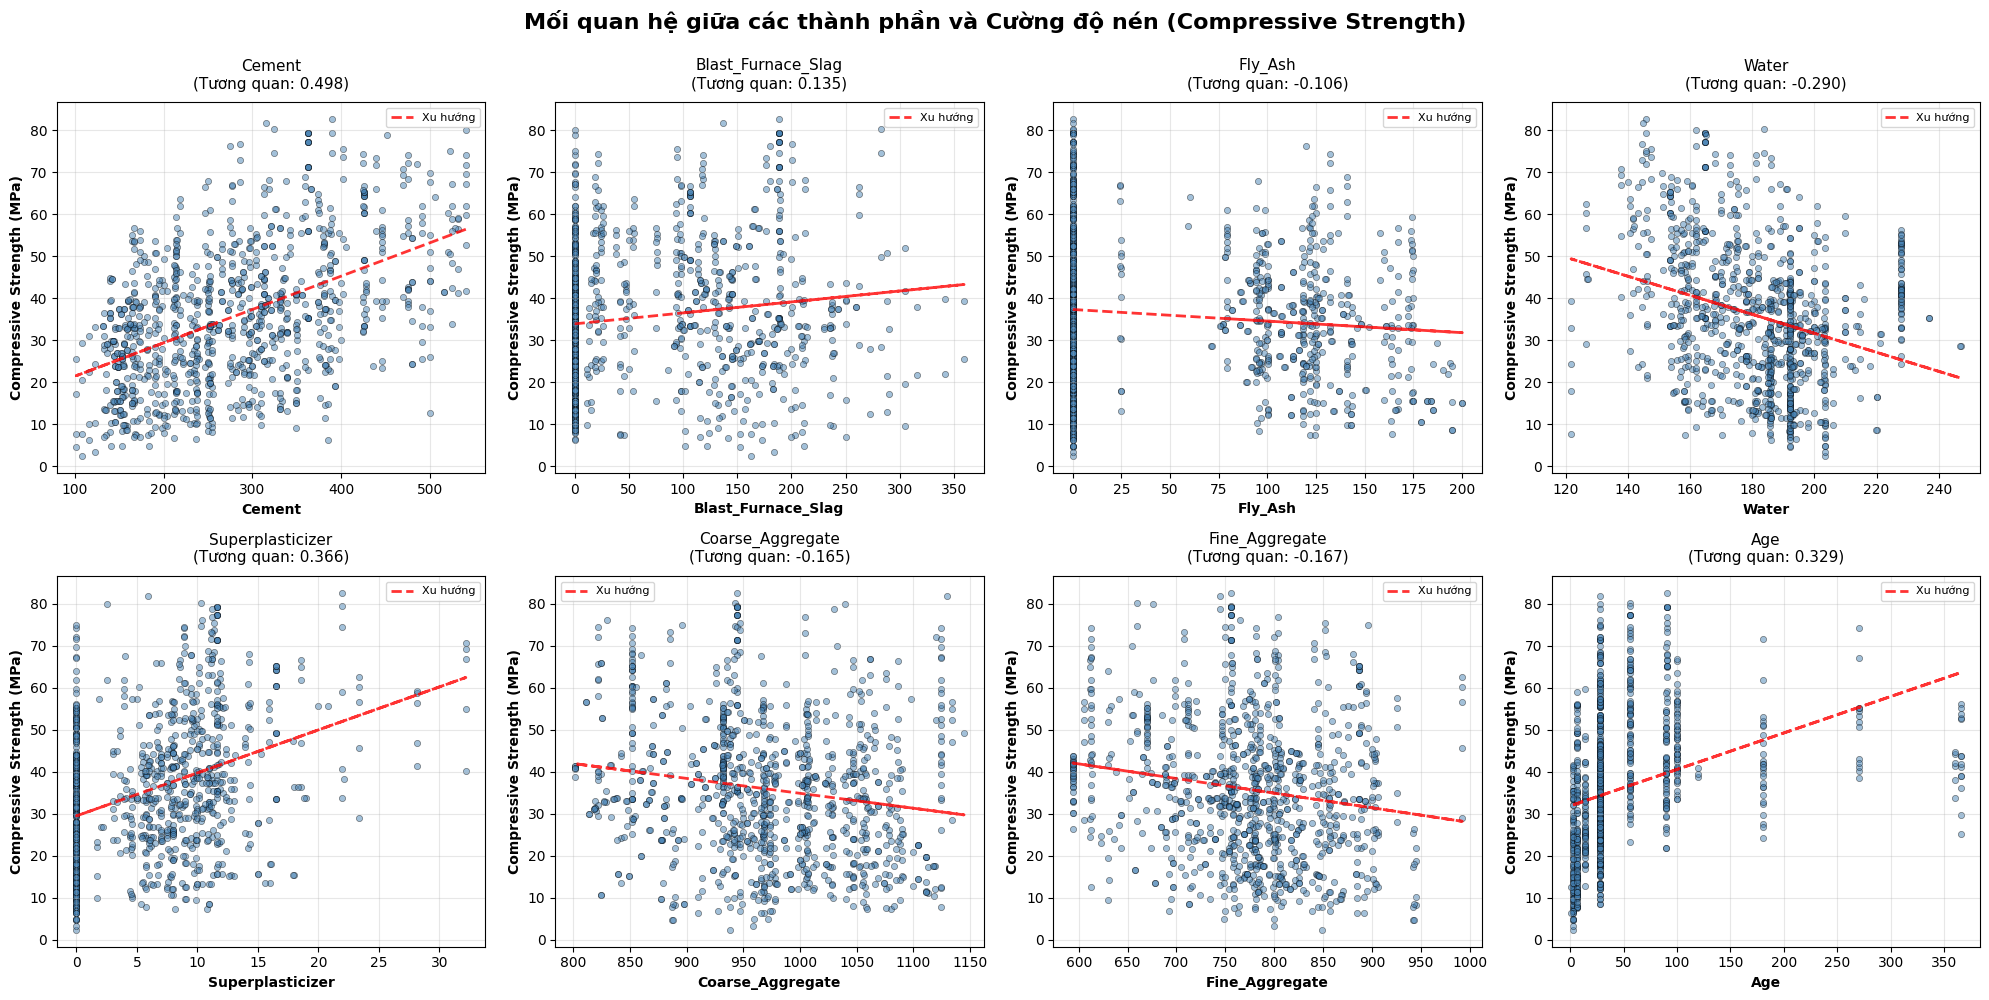


HỆ SỐ TƯƠNG QUAN VỚI COMPRESSIVE STRENGTH (TOÀN BỘ DỮ LIỆU)
Cement                   :  0.4978
Superplasticizer         :  0.3661
Age                      :  0.3289
Blast_Furnace_Slag       :  0.1348
Fly_Ash                  : -0.1058
Coarse_Aggregate         : -0.1649
Fine_Aggregate           : -0.1672
Water                    : -0.2896

KẾT QUẢ PHÁT HIỆN OUTLIERS (HAMPEL FILTER / MAD)

Cement:
  Median: 272.90
  MAD: 79.40
  Số outliers: 0 (0.0%)

Blast_Furnace_Slag:
  Median: 22.00
  MAD: 22.00
  Số outliers: 194 (18.8%)
  Giá trị outliers: min=169.00, max=359.40

Fly_Ash:
  Median: 0.00
  MAD: 0.00
  Số outliers: 0 (0.0%)

Water:
  Median: 185.00
  MAD: 13.00
  Số outliers: 0 (0.0%)

Superplasticizer:
  Median: 6.35
  MAD: 5.31
  Số outliers: 0 (0.0%)

Coarse_Aggregate:
  Median: 968.00
  MAD: 46.30
  Số outliers: 0 (0.0%)

Fine_Aggregate:
  Median: 779.51
  MAD: 45.49
  Số outliers: 0 (0.0%)

Age:
  Median: 28.00
  MAD: 21.00
  Số outliers: 59 (5.7%)
  Giá trị outliers: min=180.0

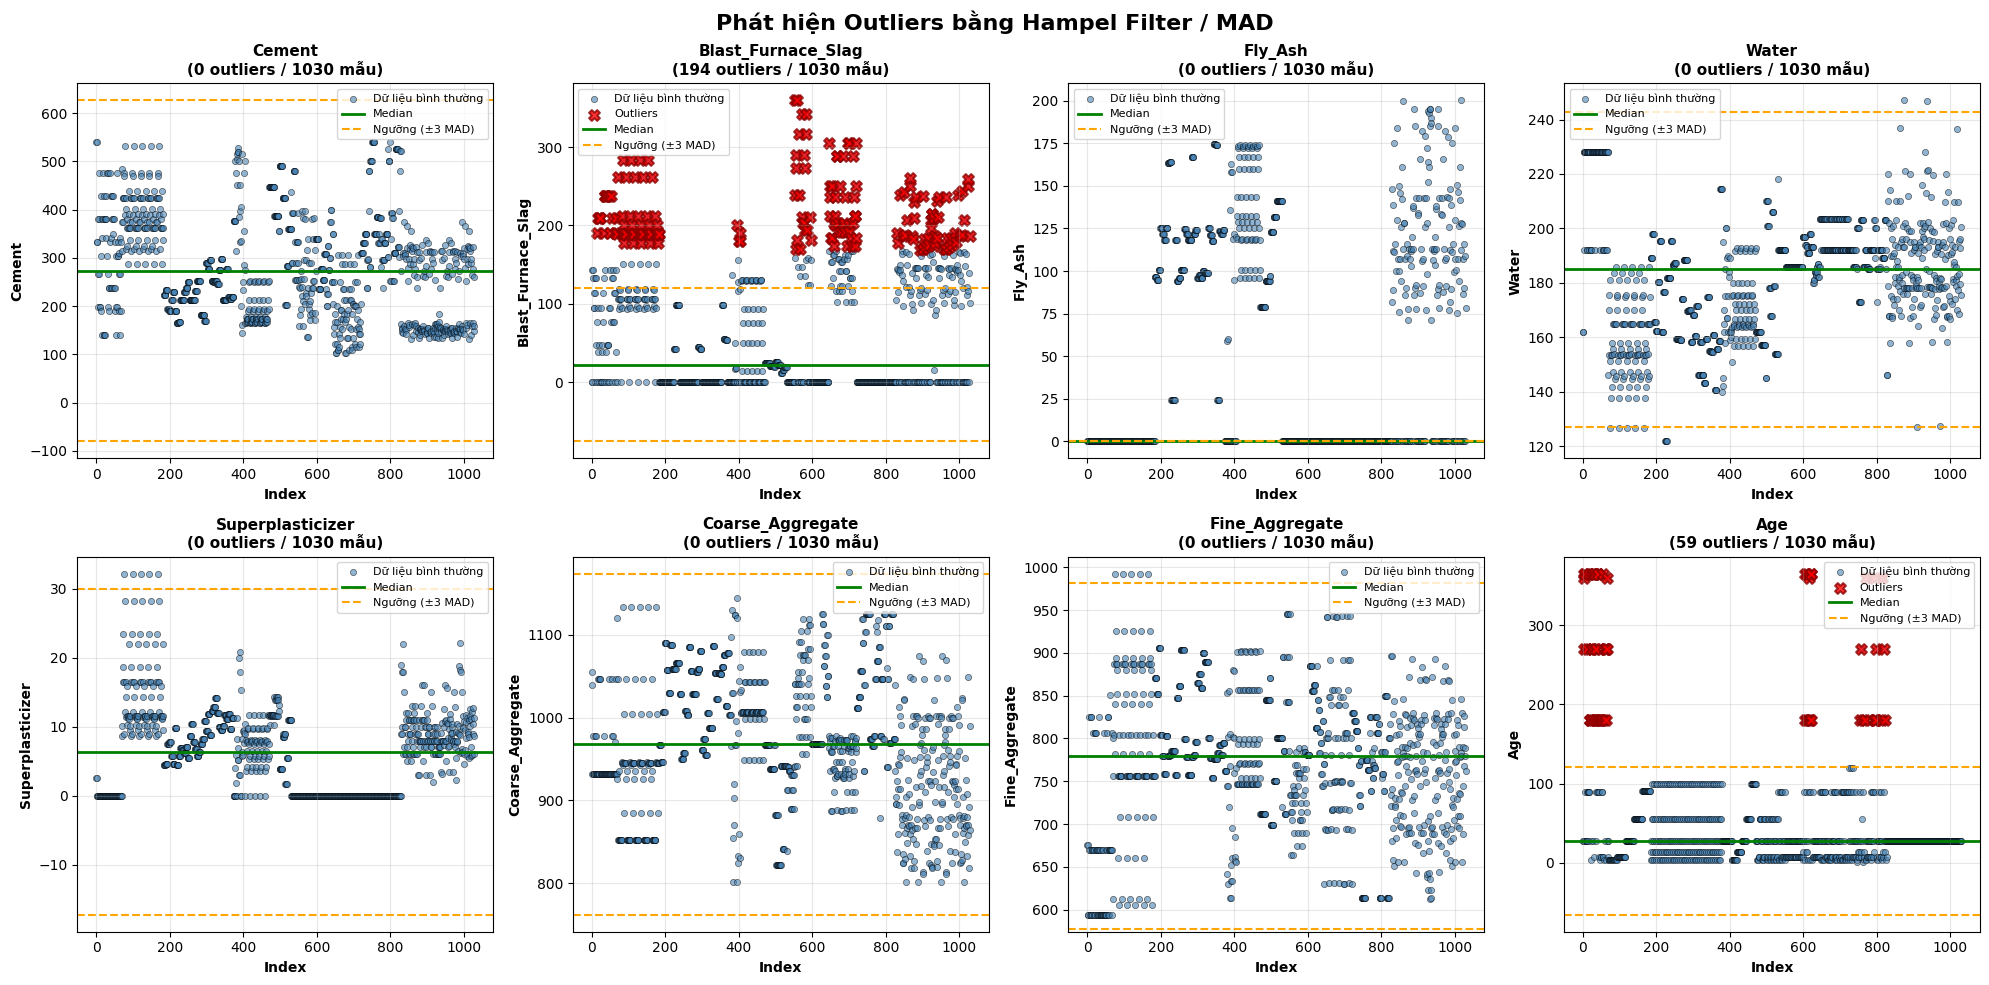


DATASET SAU KHI LOẠI BỎ OUTLIERS:
Số mẫu ban đầu: 1030
Số mẫu bị loại bỏ: 245
Số mẫu còn lại: 785
Tỷ lệ giữ lại: 76.2%

SO SÁNH HỆ SỐ TƯƠNG QUAN (TRƯỚC VÀ SAU KHI LOẠI OUTLIERS):
Feature                   Trước      Sau        Thay đổi  
----------------------------------------------------------------------
Cement                       0.4978    0.4860   -0.0119
Blast_Furnace_Slag           0.1348    0.1555   +0.0206
Fly_Ash                     -0.1058   -0.0472   +0.0585
Water                       -0.2896   -0.3561   -0.0665
Superplasticizer             0.3661    0.3824   +0.0163
Coarse_Aggregate            -0.1649   -0.1745   -0.0096
Fine_Aggregate              -0.1672   -0.1303   +0.0370
Age                          0.3289    0.5097   +0.1809

PHÁT HIỆN OUTLIERS ĐA BIẾN (PCA - Hotelling T² và Q-statistic)

Số components: 8
Phương sai giải thích bởi từng PC:
  PC1: 26.15%
  PC2: 18.80%
  PC3: 16.20%
  PC4: 12.85%
  PC5: 12.29%
  PC6: 10.84%
  PC7: 2.42%
  PC8: 0.45%
Tổng phương sai

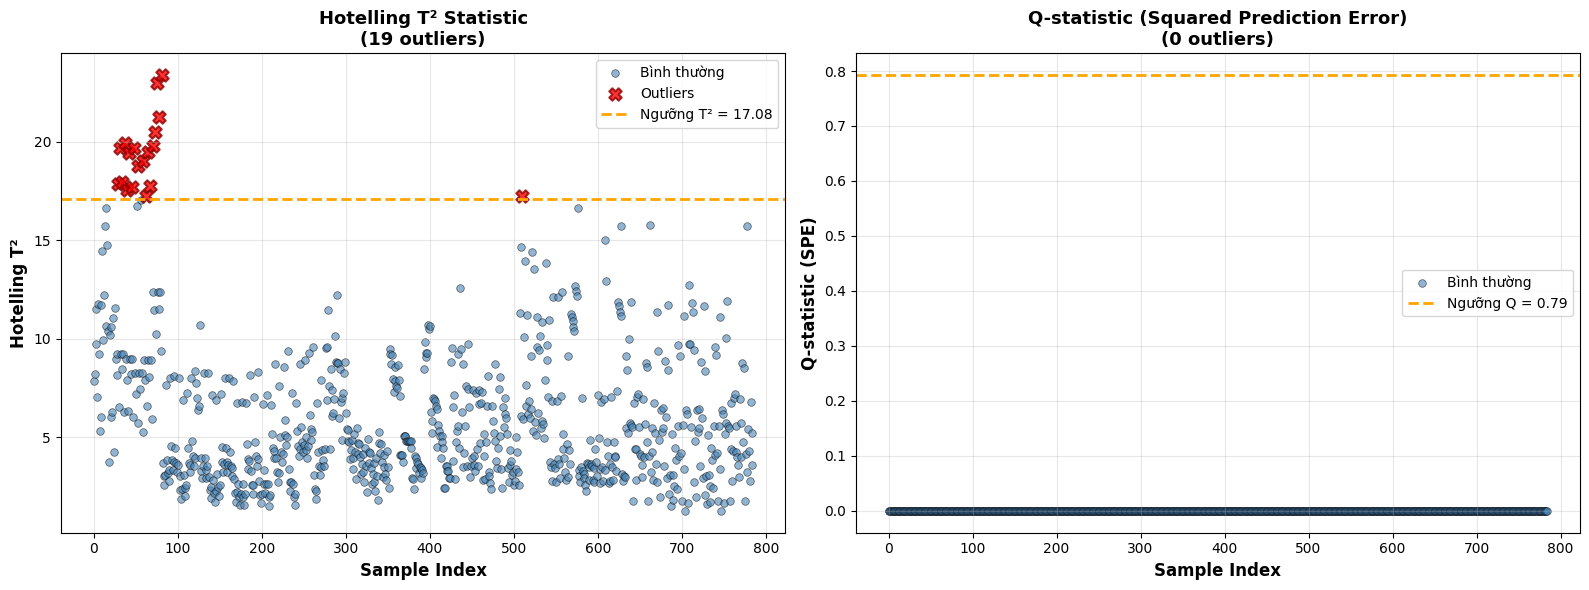

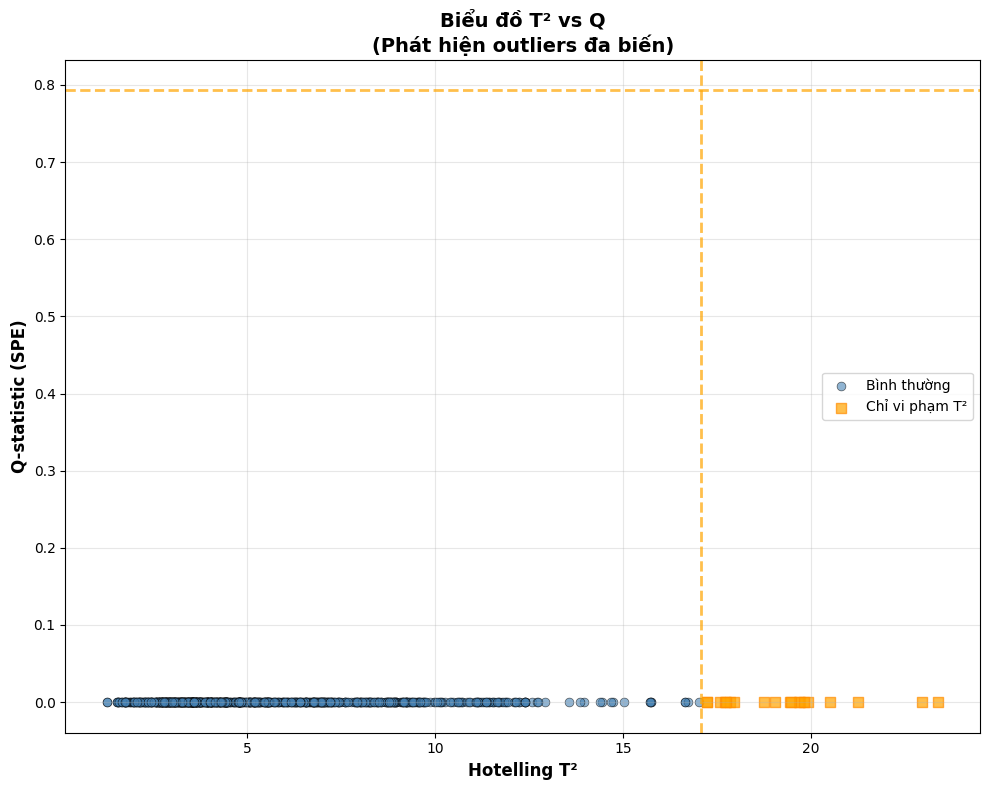


DATASET CUỐI CÙNG (SAU KHI LOẠI BỎ CẢ OUTLIERS ĐƠN BIẾN VÀ ĐA BIẾN):
Số mẫu ban đầu: 1030
Sau loại outliers đơn biến: 785 (loại bỏ 245)
Sau loại outliers đa biến: 766 (loại bỏ thêm 19)
Tổng số mẫu bị loại: 264 (25.6%)
Số mẫu còn lại: 766 (74.4%)

SO SÁNH HỆ SỐ TƯƠNG QUAN:
Feature                   Ban đầu      Loại đơn     Loại đa     
----------------------------------------------------------------------
Cement                         0.4978      0.4860      0.4687
Blast_Furnace_Slag             0.1348      0.1555      0.1383
Fly_Ash                       -0.1058     -0.0472     -0.0211
Water                         -0.2896     -0.3561     -0.3269
Superplasticizer               0.3661      0.3824      0.3461
Coarse_Aggregate              -0.1649     -0.1745     -0.1614
Fine_Aggregate                -0.1672     -0.1303     -0.1552
Age                            0.3289      0.5097      0.5123


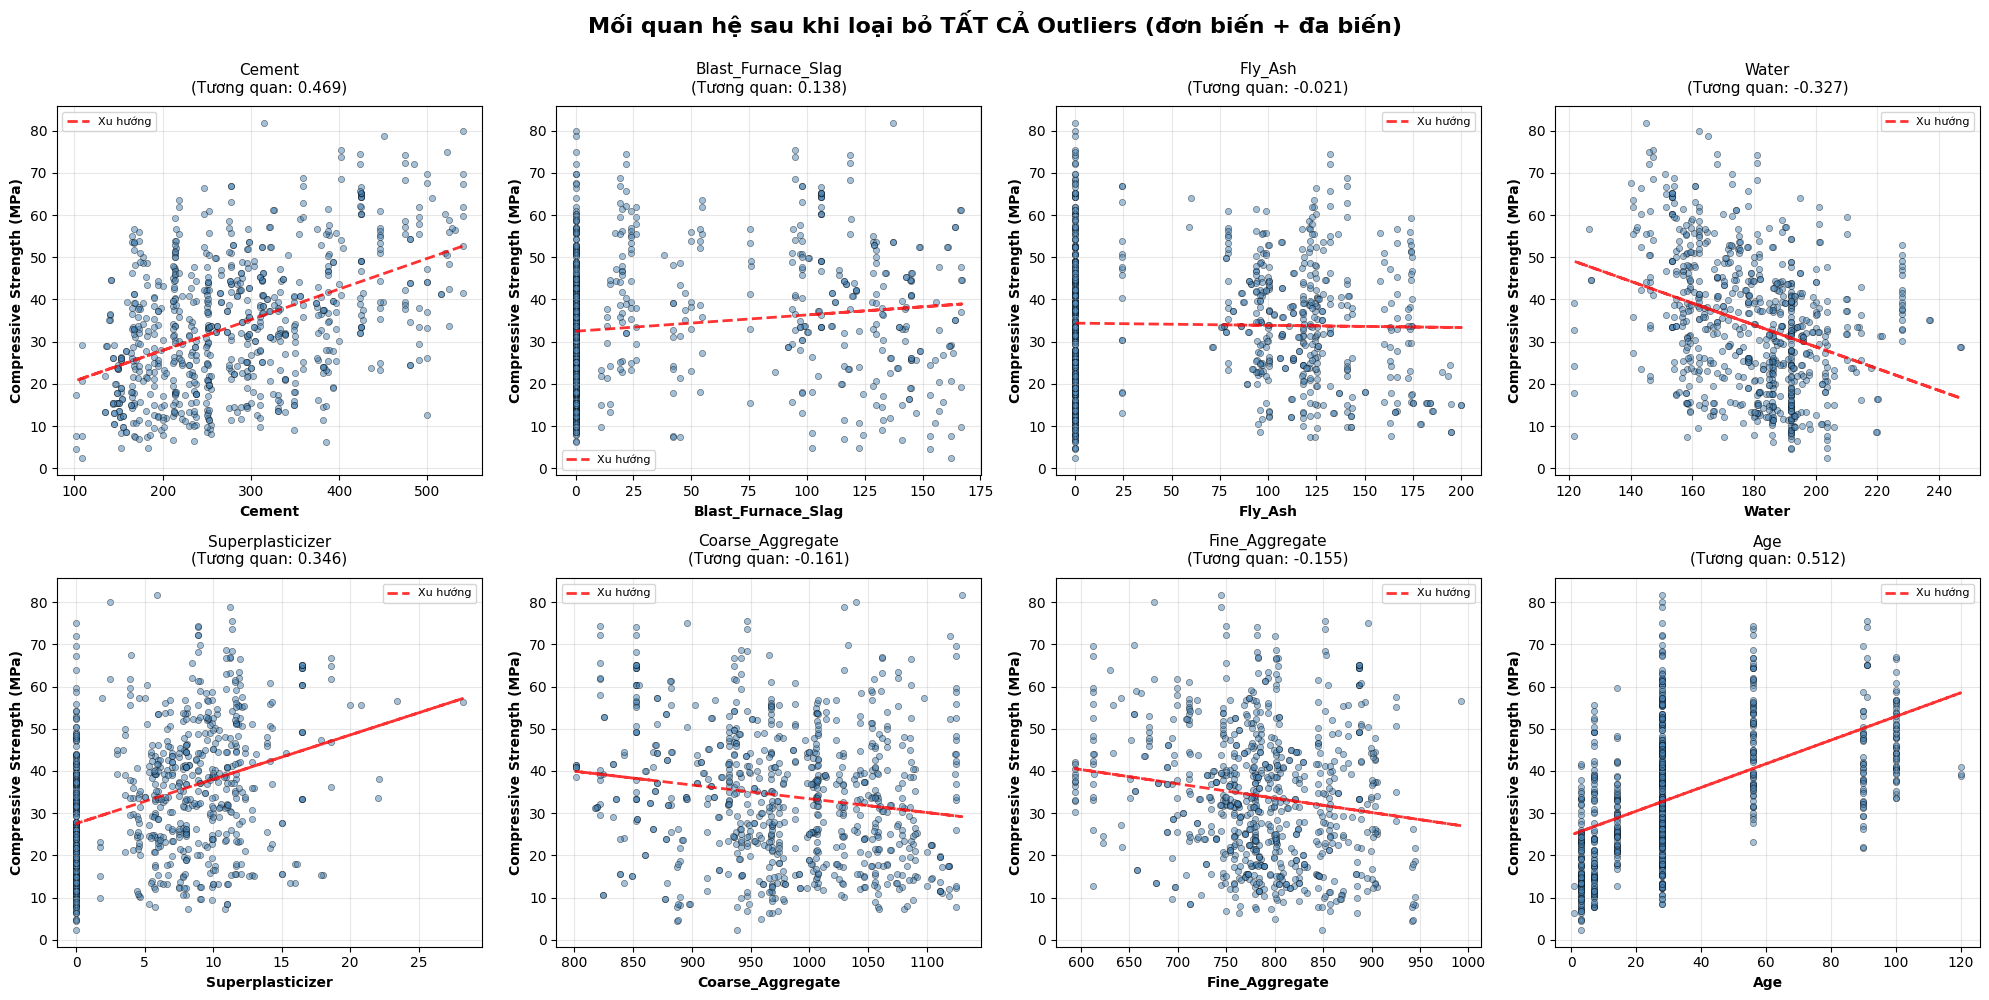

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_excel('Concrete_Data.xls', engine='xlrd')
df.columns = ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 
              'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 
              'Age', 'Compressive_Strength']

print(f"Tổng số mẫu: {len(df)}")

# ==================== HÀM PHÁT HIỆN OUTLIERS ====================

def hampel_filter_mad(data, threshold=3):
    """
    Phát hiện outliers bằng Hampel Filter / MAD
    
    Parameters:
    - data: array-like, dữ liệu đầu vào
    - threshold: float, ngưỡng (thường dùng 3)
    
    Returns:
    - outliers_mask: boolean array, True nếu là outlier
    - mad: float, giá trị MAD
    - median: float, giá trị median
    """
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    
    # Công thức chuẩn hóa MAD để tương đương với std
    mad_std = 1.4826 * mad
    
    # Tính modified z-score
    if mad_std != 0:
        modified_z_scores = 0.6745 * (data - median) / mad_std
    else:
        modified_z_scores = np.zeros_like(data)
    
    outliers_mask = np.abs(modified_z_scores) > threshold
    
    return outliers_mask, mad, median

# ==================== BƯỚC 1: VẼ BIỂU ĐỒ SCATTER ====================

features = ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 
            'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 'Age']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Mối quan hệ giữa các thành phần và Cường độ nén (Compressive Strength)', 
             fontsize=16, fontweight='bold', y=0.995)

for idx, feature in enumerate(features):
    row = idx // 4
    col = idx % 4
    ax = axes[row, col]
    
    # Vẽ scatter plot với feature là trục x, Compressive_Strength là trục y
    ax.scatter(df[feature], df['Compressive_Strength'], 
               alpha=0.5, s=20, c='steelblue', edgecolors='black', linewidth=0.5)
    
    # Thêm đường xu hướng (trendline)
    z = np.polyfit(df[feature], df['Compressive_Strength'], 1)
    p = np.poly1d(z)
    ax.plot(df[feature], p(df[feature]), 
            "r--", alpha=0.8, linewidth=2, label='Xu hướng')
    
    # Tính hệ số tương quan
    correlation = df['Compressive_Strength'].corr(df[feature])
    
    ax.set_xlabel(f'{feature}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Compressive Strength (MPa)', fontsize=10, fontweight='bold')
    ax.set_title(f'{feature}\n(Tương quan: {correlation:.3f})', 
                 fontsize=11, pad=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Tạo bảng hệ số tương quan
print("\n" + "="*70)
print("HỆ SỐ TƯƠNG QUAN VỚI COMPRESSIVE STRENGTH (TOÀN BỘ DỮ LIỆU)")
print("="*70)
correlations = df[features].corrwith(df['Compressive_Strength']).sort_values(ascending=False)
for feature, corr in correlations.items():
    print(f"{feature:25s}: {corr:7.4f}")
print("="*70)

# ==================== BƯỚC 2: PHÁT HIỆN OUTLIERS ====================

threshold = 3  # Ngưỡng MAD
outlier_summary = {}
all_outliers_mask = np.zeros(len(df), dtype=bool)

print("\n" + "="*70)
print("KẾT QUẢ PHÁT HIỆN OUTLIERS (HAMPEL FILTER / MAD)")
print("="*70)

for feature in features:
    outliers_mask, mad, median = hampel_filter_mad(df[feature].values, threshold)
    
    num_outliers = outliers_mask.sum()
    outlier_percentage = (num_outliers / len(df)) * 100
    
    outlier_summary[feature] = {
        'count': num_outliers,
        'percentage': outlier_percentage,
        'mad': mad,
        'median': median,
        'mask': outliers_mask
    }
    
    # Cộng dồn mask (nếu bất kỳ biến nào có outlier)
    all_outliers_mask |= outliers_mask
    
    print(f"\n{feature}:")
    print(f"  Median: {median:.2f}")
    print(f"  MAD: {mad:.2f}")
    print(f"  Số outliers: {num_outliers} ({outlier_percentage:.1f}%)")
    
    if num_outliers > 0:
        outlier_values = df[feature].values[outliers_mask]
        print(f"  Giá trị outliers: min={outlier_values.min():.2f}, max={outlier_values.max():.2f}")

print("\n" + "="*70)
print(f"TỔNG SỐ MẪU CÓ ÍT NHẤT 1 OUTLIER: {all_outliers_mask.sum()} ({all_outliers_mask.sum()/len(df)*100:.1f}%)")
print("="*70)

# ==================== BƯỚC 3: VISUALIZATION OUTLIERS ====================

fig2, axes2 = plt.subplots(2, 4, figsize=(20, 10))
fig2.suptitle('Phát hiện Outliers bằng Hampel Filter / MAD', fontsize=16, fontweight='bold')

for idx, feature in enumerate(features):
    row = idx // 4
    col = idx % 4
    ax = axes2[row, col]
    
    data = df[feature].values
    outliers_mask = outlier_summary[feature]['mask']
    median = outlier_summary[feature]['median']
    mad = outlier_summary[feature]['mad']
    mad_std = 1.4826 * mad
    
    # Vẽ dữ liệu bình thường
    ax.scatter(range(len(data)), data, c='steelblue', alpha=0.6, s=20, 
               label='Dữ liệu bình thường', edgecolors='black', linewidth=0.5)
    
    # Vẽ outliers
    if outliers_mask.sum() > 0:
        ax.scatter(np.where(outliers_mask)[0], data[outliers_mask], 
                   c='red', alpha=0.8, s=60, label='Outliers', 
                   edgecolors='darkred', linewidth=1.5, marker='X')
    
    # Vẽ đường median và ngưỡng
    ax.axhline(y=median, color='green', linestyle='-', linewidth=2, label='Median')
    ax.axhline(y=median + threshold * mad_std, color='orange', linestyle='--', 
               linewidth=1.5, label=f'Ngưỡng (±{threshold} MAD)')
    ax.axhline(y=median - threshold * mad_std, color='orange', linestyle='--', linewidth=1.5)
    
    ax.set_xlabel('Index', fontsize=10, fontweight='bold')
    ax.set_ylabel(f'{feature}', fontsize=10, fontweight='bold')
    ax.set_title(f'{feature}\n({outliers_mask.sum()} outliers / {len(data)} mẫu)', 
                 fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

# ==================== BƯỚC 4: TẠO DATASET SẠCH ====================

df_clean = df[~all_outliers_mask].copy()

print(f"\n{'='*70}")
print(f"DATASET SAU KHI LOẠI BỎ OUTLIERS:")
print(f"{'='*70}")
print(f"Số mẫu ban đầu: {len(df)}")
print(f"Số mẫu bị loại bỏ: {all_outliers_mask.sum()}")
print(f"Số mẫu còn lại: {len(df_clean)}")
print(f"Tỷ lệ giữ lại: {len(df_clean)/len(df)*100:.1f}%")

# So sánh correlation trước và sau
print(f"\n{'='*70}")
print("SO SÁNH HỆ SỐ TƯƠNG QUAN (TRƯỚC VÀ SAU KHI LOẠI OUTLIERS):")
print(f"{'='*70}")
print(f"{'Feature':<25} {'Trước':<10} {'Sau':<10} {'Thay đổi':<10}")
print("-"*70)

for feature in features:
    corr_before = df['Compressive_Strength'].corr(df[feature])
    corr_after = df_clean['Compressive_Strength'].corr(df_clean[feature])
    change = corr_after - corr_before
    
    print(f"{feature:<25} {corr_before:>9.4f} {corr_after:>9.4f} {change:>+9.4f}")

print("="*70)

# ==================== BƯỚC 5: PHÁT HIỆN OUTLIERS ĐA BIẾN (PCA) ====================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import chi2

print(f"\n{'='*70}")
print("PHÁT HIỆN OUTLIERS ĐA BIẾN (PCA - Hotelling T² và Q-statistic)")
print(f"{'='*70}")

# Chuẩn bị dữ liệu: sử dụng df_clean (đã loại bỏ outliers đơn biến)
X = df_clean[features].values
y = df_clean['Compressive_Strength'].values

# Chuẩn hóa dữ liệu (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Áp dụng PCA
n_components = len(features)  # Giữ tất cả components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# In phương sai giải thích
print(f"\nSố components: {n_components}")
print(f"Phương sai giải thích bởi từng PC:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.2f}%")
print(f"Tổng phương sai giải thích: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Chọn số PC để giữ lại (ví dụ: 95% variance)
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
n_pc_95 = np.argmax(cumsum_var >= 0.95) + 1
print(f"\nSố PC cần để giữ 95% variance: {n_pc_95}")

# ----- HOTELLING T² STATISTIC -----
# T² đo khoảng cách của mẫu trong không gian PC chính
n_samples = X_pca.shape[0]
n_pc = n_pc_95  # Sử dụng số PC giải thích 95% variance

# Tính T² cho từng mẫu
T2 = np.sum((X_pca[:, :n_pc] ** 2) / pca.explained_variance_[:n_pc], axis=1)

# Ngưỡng T² (dựa trên phân phối F)
# Sử dụng confidence level 95% hoặc 99%
alpha = 0.01  # 99% confidence
from scipy.stats import f
T2_threshold = (n_pc * (n_samples - 1) * (n_samples + 1)) / \
               (n_samples * (n_samples - n_pc)) * \
               f.ppf(1 - alpha, n_pc, n_samples - n_pc)

T2_outliers = T2 > T2_threshold
n_T2_outliers = T2_outliers.sum()

print(f"\n--- Hotelling T² Statistic ---")
print(f"Số PC sử dụng: {n_pc}")
print(f"Ngưỡng T² (α={alpha}): {T2_threshold:.2f}")
print(f"T² max: {T2.max():.2f}")
print(f"Số outliers phát hiện: {n_T2_outliers} ({n_T2_outliers/n_samples*100:.1f}%)")

# ----- Q-STATISTIC (SPE - Squared Prediction Error) -----
# Q đo độ lệch của mẫu khỏi không gian PC (phần dư)
X_reconstructed = pca.inverse_transform(X_pca)
Q = np.sum((X_scaled - X_reconstructed) ** 2, axis=1)

# Ngưỡng Q (dựa trên phân phối chi-squared xấp xỉ)
# Sử dụng công thức Jackson-Mudholkar
theta = [np.sum(pca.explained_variance_[n_pc:] ** i) for i in range(1, 4)]
h0 = 1 - (2 * theta[0] * theta[2]) / (3 * theta[1] ** 2)

Q_threshold = theta[0] * (
    1 - (theta[1] * h0 * (1 - h0)) / theta[0] ** 2 +
    chi2.ppf(1 - alpha, h0 ** 2) * np.sqrt(2 * theta[1] * h0 ** 2) / theta[0]
) ** (1 / h0)

Q_outliers = Q > Q_threshold
n_Q_outliers = Q_outliers.sum()

print(f"\n--- Q-statistic (SPE) ---")
print(f"Ngưỡng Q (α={alpha}): {Q_threshold:.2f}")
print(f"Q max: {Q.max():.2f}")
print(f"Số outliers phát hiện: {n_Q_outliers} ({n_Q_outliers/n_samples*100:.1f}%)")

# Kết hợp cả hai tiêu chí
multivariate_outliers = T2_outliers | Q_outliers
n_multi_outliers = multivariate_outliers.sum()

print(f"\n--- Kết hợp T² và Q ---")
print(f"Tổng số outliers đa biến: {n_multi_outliers} ({n_multi_outliers/n_samples*100:.1f}%)")

# Visualization: T² vs Q
fig_pca, axes_pca = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: T² chart
ax1 = axes_pca[0]
indices = np.arange(len(T2))
normal_indices = indices[~T2_outliers]
outlier_indices = indices[T2_outliers]

ax1.scatter(normal_indices, T2[~T2_outliers], c='steelblue', alpha=0.6, s=30, 
           label='Bình thường', edgecolors='black', linewidth=0.5)
if n_T2_outliers > 0:
    ax1.scatter(outlier_indices, T2[T2_outliers], 
               c='red', alpha=0.8, s=80, label='Outliers', 
               edgecolors='darkred', linewidth=1.5, marker='X')
ax1.axhline(y=T2_threshold, color='orange', linestyle='--', linewidth=2, 
           label=f'Ngưỡng T² = {T2_threshold:.2f}')
ax1.set_xlabel('Sample Index', fontsize=12, fontweight='bold')
ax1.set_ylabel('Hotelling T²', fontsize=12, fontweight='bold')
ax1.set_title(f'Hotelling T² Statistic\n({n_T2_outliers} outliers)', 
             fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Plot 2: Q chart
ax2 = axes_pca[1]
normal_indices_q = indices[~Q_outliers]
outlier_indices_q = indices[Q_outliers]

ax2.scatter(normal_indices_q, Q[~Q_outliers], c='steelblue', alpha=0.6, s=30, 
           label='Bình thường', edgecolors='black', linewidth=0.5)
if n_Q_outliers > 0:
    ax2.scatter(outlier_indices_q, Q[Q_outliers], 
               c='red', alpha=0.8, s=80, label='Outliers', 
               edgecolors='darkred', linewidth=1.5, marker='X')
ax2.axhline(y=Q_threshold, color='orange', linestyle='--', linewidth=2, 
           label=f'Ngưỡng Q = {Q_threshold:.2f}')
ax2.set_xlabel('Sample Index', fontsize=12, fontweight='bold')
ax2.set_ylabel('Q-statistic (SPE)', fontsize=12, fontweight='bold')
ax2.set_title(f'Q-statistic (Squared Prediction Error)\n({n_Q_outliers} outliers)', 
             fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# T² vs Q scatter plot
fig_scatter = plt.figure(figsize=(10, 8))
ax_scatter = fig_scatter.add_subplot(111)

# Vẽ 4 vùng
both_normal = ~T2_outliers & ~Q_outliers
only_T2 = T2_outliers & ~Q_outliers
only_Q = ~T2_outliers & Q_outliers
both_outlier = T2_outliers & Q_outliers

ax_scatter.scatter(T2[both_normal], Q[both_normal], c='steelblue', alpha=0.6, 
                  s=40, label='Bình thường', edgecolors='black', linewidth=0.5)
if only_T2.sum() > 0:
    ax_scatter.scatter(T2[only_T2], Q[only_T2], c='orange', alpha=0.7, 
                      s=60, label='Chỉ vi phạm T²', edgecolors='darkorange', linewidth=1, marker='s')
if only_Q.sum() > 0:
    ax_scatter.scatter(T2[only_Q], Q[only_Q], c='purple', alpha=0.7, 
                      s=60, label='Chỉ vi phạm Q', edgecolors='indigo', linewidth=1, marker='^')
if both_outlier.sum() > 0:
    ax_scatter.scatter(T2[both_outlier], Q[both_outlier], c='red', alpha=0.9, 
                      s=100, label='Vi phạm cả 2', edgecolors='darkred', linewidth=1.5, marker='X')

ax_scatter.axhline(y=Q_threshold, color='orange', linestyle='--', linewidth=2, alpha=0.7)
ax_scatter.axvline(x=T2_threshold, color='orange', linestyle='--', linewidth=2, alpha=0.7)
ax_scatter.set_xlabel('Hotelling T²', fontsize=12, fontweight='bold')
ax_scatter.set_ylabel('Q-statistic (SPE)', fontsize=12, fontweight='bold')
ax_scatter.set_title('Biểu đồ T² vs Q\n(Phát hiện outliers đa biến)', 
                    fontsize=14, fontweight='bold')
ax_scatter.grid(True, alpha=0.3)
ax_scatter.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.show()

# Tạo dataset cuối cùng (loại bỏ cả outliers đơn biến và đa biến)
df_final = df_clean[~multivariate_outliers].copy()

print(f"\n{'='*70}")
print(f"DATASET CUỐI CÙNG (SAU KHI LOẠI BỎ CẢ OUTLIERS ĐƠN BIẾN VÀ ĐA BIẾN):")
print(f"{'='*70}")
print(f"Số mẫu ban đầu: {len(df)}")
print(f"Sau loại outliers đơn biến: {len(df_clean)} (loại bỏ {len(df) - len(df_clean)})")
print(f"Sau loại outliers đa biến: {len(df_final)} (loại bỏ thêm {n_multi_outliers})")
print(f"Tổng số mẫu bị loại: {len(df) - len(df_final)} ({(len(df) - len(df_final))/len(df)*100:.1f}%)")
print(f"Số mẫu còn lại: {len(df_final)} ({len(df_final)/len(df)*100:.1f}%)")

# So sánh correlation sau tất cả các bước
print(f"\n{'='*70}")
print("SO SÁNH HỆ SỐ TƯƠNG QUAN:")
print(f"{'='*70}")
print(f"{'Feature':<25} {'Ban đầu':<12} {'Loại đơn':<12} {'Loại đa':<12}")
print("-"*70)

for feature in features:
    corr_original = df['Compressive_Strength'].corr(df[feature])
    corr_univariate = df_clean['Compressive_Strength'].corr(df_clean[feature])
    corr_multivariate = df_final['Compressive_Strength'].corr(df_final[feature])
    
    print(f"{feature:<25} {corr_original:>11.4f} {corr_univariate:>11.4f} {corr_multivariate:>11.4f}")

print("="*70)

# ==================== BƯỚC 6: VẼ LẠI BIỂU ĐỒ SAU KHI LOẠI TẤT CẢ OUTLIERS ====================

fig3, axes3 = plt.subplots(2, 4, figsize=(20, 10))
fig3.suptitle('Mối quan hệ sau khi loại bỏ TẤT CẢ Outliers (đơn biến + đa biến)', 
             fontsize=16, fontweight='bold', y=0.995)

for idx, feature in enumerate(features):
    row = idx // 4
    col = idx % 4
    ax = axes3[row, col]
    
    # Vẽ scatter plot với dữ liệu cuối cùng (đã loại outliers đa biến)
    ax.scatter(df_final[feature], df_final['Compressive_Strength'], 
               alpha=0.5, s=20, c='steelblue', edgecolors='black', linewidth=0.5)
    
    # Thêm đường xu hướng
    z = np.polyfit(df_final[feature], df_final['Compressive_Strength'], 1)
    p = np.poly1d(z)
    ax.plot(df_final[feature], p(df_final[feature]), 
            "r--", alpha=0.8, linewidth=2, label='Xu hướng')
    
    # Tính hệ số tương quan cuối cùng
    correlation = df_final['Compressive_Strength'].corr(df_final[feature])
    
    ax.set_xlabel(f'{feature}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Compressive Strength (MPa)', fontsize=10, fontweight='bold')
    ax.set_title(f'{feature}\n(Tương quan: {correlation:.3f})', 
                 fontsize=11, pad=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Tổng số mẫu: 1030

THỐNG KÊ CÁC CHỈ SỐ KỸ THUẬT:
--------------------------------------------------------------------------------
W/C ratio - Mean: 0.748, Min: 0.267, Max: 1.882
W/B ratio - Mean: 0.469, Min: 0.235, Max: 0.900
Total Binder - Mean: 409.2, Min: 200.0, Max: 640.0

KIỂM TRA CÁC QUY TẮC DOMAIN KNOWLEDGE

Tổng số mẫu vi phạm: 505 / 1030 (49.0%)

Số lượng vi phạm từng loại:
--------------------------------------------------------------------------------
High Wc High Strength                             :    43 (4.2%)
Low Age High Strength                             :     5 (0.5%)
Low Cement High Strength                          :    12 (1.2%)
Superplasticizer High Wc                          :   484 (47.0%)
High Age Low Strength                             :     1 (0.1%)

MỘT SỐ MẪU VI PHẠM (10 MẪU ĐẦU TIÊN):
 Index  Cement  Water  WC_ratio  Superplasticizer   Age  Compressive_Strength                                                  Violations
    17   342.0  228.0  0.66666

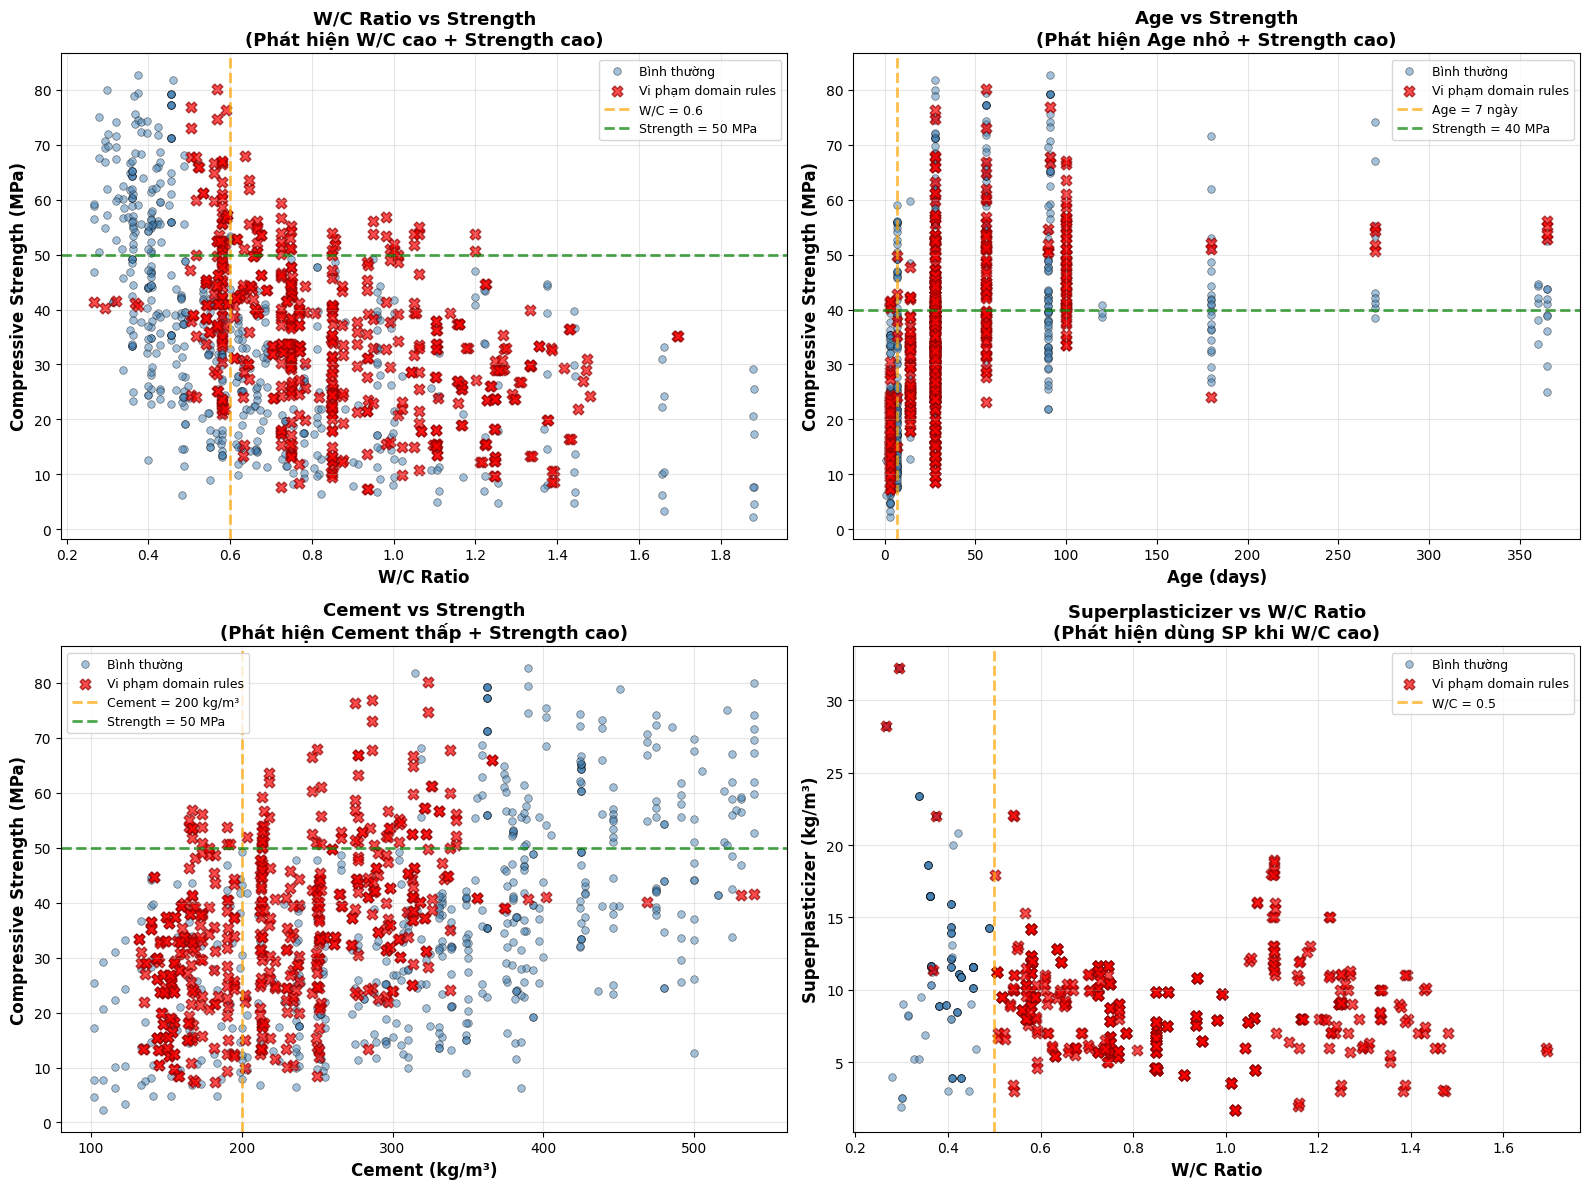


QUYẾT ĐỊNH XỬ LÝ:
Các mẫu vi phạm domain knowledge có thể:
1. Là dữ liệu SAI (measurement error, data entry error)
2. Là công thức ĐẶC BIỆT (sử dụng phụ gia đặc biệt, công nghệ mới)
3. Cần XEM XÉT TỪNG TRƯỜNG HỢP với chuyên gia

Khuyến nghị: KHÔNG TỰ Ý XÓA mà nên:
- Kiểm tra lại nguồn dữ liệu
- Tham khảo chuyên gia kỹ thuật
- Nếu chắc chắn là lỗi → Loại bỏ
- Nếu là công nghệ mới → Giữ lại và ghi chú

Nếu loại bỏ TẤT CẢ vi phạm:
Số mẫu ban đầu: 1030
Số mẫu còn lại: 525 (51.0%)


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Đọc dữ liệu (sử dụng df_final từ bước trước - đã loại outliers)
# Hoặc có thể dùng df gốc nếu muốn kiểm tra trước khi loại outliers
df = pd.read_excel('Concrete_Data.xls', engine='xlrd')
df.columns = ['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 
              'Superplasticizer', 'Coarse_Aggregate', 'Fine_Aggregate', 
              'Age', 'Compressive_Strength']

print(f"Tổng số mẫu: {len(df)}")
print("="*80)

# ==================== TÍNH CÁC CHỈ SỐ KỸ THUẬT ====================

# Tính tỷ lệ Water/Cement (W/C ratio)
df['WC_ratio'] = df['Water'] / df['Cement']

# Tính tổng chất kết dính (binder)
df['Total_Binder'] = df['Cement'] + df['Blast_Furnace_Slag'] + df['Fly_Ash']

# Tính tỷ lệ Water/Binder
df['WB_ratio'] = df['Water'] / df['Total_Binder']

print("\nTHỐNG KÊ CÁC CHỈ SỐ KỸ THUẬT:")
print("-"*80)
print(f"W/C ratio - Mean: {df['WC_ratio'].mean():.3f}, Min: {df['WC_ratio'].min():.3f}, Max: {df['WC_ratio'].max():.3f}")
print(f"W/B ratio - Mean: {df['WB_ratio'].mean():.3f}, Min: {df['WB_ratio'].min():.3f}, Max: {df['WB_ratio'].max():.3f}")
print(f"Total Binder - Mean: {df['Total_Binder'].mean():.1f}, Min: {df['Total_Binder'].min():.1f}, Max: {df['Total_Binder'].max():.1f}")

# ==================== ĐỊNH NGHĨA CÁC QUY TẮC DOMAIN KNOWLEDGE ====================

def check_domain_rules(df):
    """
    Kiểm tra các quy tắc domain knowledge cho bê tông
    
    Returns:
    - violations: DataFrame chứa các mẫu vi phạm
    - violation_types: Dictionary đếm số lượng vi phạm từng loại
    """
    
    violations = []
    violation_types = {
        'high_wc_high_strength': 0,
        'low_age_high_strength': 0,
        'low_cement_high_strength': 0,
        'superplasticizer_high_wc': 0,
        'low_wc_low_strength': 0,
        'high_age_low_strength': 0
    }
    
    for idx, row in df.iterrows():
        sample_violations = []
        
        # QUY TẮC 1: W/C cao (>0.6) nhưng Strength cao (>50 MPa)
        if row['WC_ratio'] > 0.6 and row['Compressive_Strength'] > 50:
            sample_violations.append('W/C cao nhưng Strength cao')
            violation_types['high_wc_high_strength'] += 1
        
        # QUY TẮC 2: Age nhỏ (<7 ngày) nhưng Strength rất cao (>40 MPa)
        if row['Age'] < 7 and row['Compressive_Strength'] > 40:
            sample_violations.append('Age nhỏ nhưng Strength cao')
            violation_types['low_age_high_strength'] += 1
        
        # QUY TẮC 3: Cement thấp (<200) nhưng Strength cao (>50 MPa)
        if row['Cement'] < 200 and row['Compressive_Strength'] > 50:
            sample_violations.append('Cement thấp nhưng Strength cao')
            violation_types['low_cement_high_strength'] += 1
        
        # QUY TẮC 4: Dùng Superplasticizer (>0) nhưng W/C cao (>0.5)
        if row['Superplasticizer'] > 0 and row['WC_ratio'] > 0.5:
            sample_violations.append('Superplasticizer không cần thiết (W/C cao)')
            violation_types['superplasticizer_high_wc'] += 1
        
        # QUY TẮC 5: W/C rất thấp (<0.3) nhưng Strength thấp (<30 MPa) - nghi ngờ
        if row['WC_ratio'] < 0.3 and row['Compressive_Strength'] < 30:
            sample_violations.append('W/C thấp nhưng Strength thấp (bất thường)')
            violation_types['low_wc_low_strength'] += 1
        
        # QUY TẮC 6: Age cao (>90 ngày) nhưng Strength thấp (<25 MPa) - nghi ngờ chất lượng
        if row['Age'] > 90 and row['Compressive_Strength'] < 25:
            sample_violations.append('Age cao nhưng Strength thấp')
            violation_types['high_age_low_strength'] += 1
        
        # Nếu có vi phạm, lưu lại
        if sample_violations:
            violations.append({
                'Index': idx,
                'Cement': row['Cement'],
                'Water': row['Water'],
                'WC_ratio': row['WC_ratio'],
                'Superplasticizer': row['Superplasticizer'],
                'Age': row['Age'],
                'Compressive_Strength': row['Compressive_Strength'],
                'Violations': ' | '.join(sample_violations)
            })
    
    return pd.DataFrame(violations), violation_types

# ==================== THỰC HIỆN KIỂM TRA ====================

print("\n" + "="*80)
print("KIỂM TRA CÁC QUY TẮC DOMAIN KNOWLEDGE")
print("="*80)

violations_df, violation_counts = check_domain_rules(df)

print(f"\nTổng số mẫu vi phạm: {len(violations_df)} / {len(df)} ({len(violations_df)/len(df)*100:.1f}%)")
print("\nSố lượng vi phạm từng loại:")
print("-"*80)
for rule, count in violation_counts.items():
    if count > 0:
        rule_name = rule.replace('_', ' ').title()
        print(f"{rule_name:<50}: {count:>5} ({count/len(df)*100:.1f}%)")

# Hiển thị một số mẫu vi phạm
if len(violations_df) > 0:
    print("\n" + "="*80)
    print("MỘT SỐ MẪU VI PHẠM (10 MẪU ĐẦU TIÊN):")
    print("="*80)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', 50)
    print(violations_df.head(10).to_string(index=False))

# ==================== VISUALIZATION ====================

# Vẽ biểu đồ W/C ratio vs Strength
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: W/C ratio vs Strength
ax1 = axes[0, 0]
normal_mask = ~df.index.isin(violations_df['Index'])
ax1.scatter(df.loc[normal_mask, 'WC_ratio'], 
           df.loc[normal_mask, 'Compressive_Strength'],
           c='steelblue', alpha=0.5, s=30, label='Bình thường',
           edgecolors='black', linewidth=0.5)
if len(violations_df) > 0:
    ax1.scatter(df.loc[violations_df['Index'], 'WC_ratio'],
               df.loc[violations_df['Index'], 'Compressive_Strength'],
               c='red', alpha=0.7, s=60, label='Vi phạm domain rules',
               edgecolors='darkred', linewidth=1, marker='X')
ax1.axvline(x=0.6, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='W/C = 0.6')
ax1.axhline(y=50, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Strength = 50 MPa')
ax1.set_xlabel('W/C Ratio', fontsize=12, fontweight='bold')
ax1.set_ylabel('Compressive Strength (MPa)', fontsize=12, fontweight='bold')
ax1.set_title('W/C Ratio vs Strength\n(Phát hiện W/C cao + Strength cao)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)

# Plot 2: Age vs Strength
ax2 = axes[0, 1]
ax2.scatter(df.loc[normal_mask, 'Age'], 
           df.loc[normal_mask, 'Compressive_Strength'],
           c='steelblue', alpha=0.5, s=30, label='Bình thường',
           edgecolors='black', linewidth=0.5)
if len(violations_df) > 0:
    ax2.scatter(df.loc[violations_df['Index'], 'Age'],
               df.loc[violations_df['Index'], 'Compressive_Strength'],
               c='red', alpha=0.7, s=60, label='Vi phạm domain rules',
               edgecolors='darkred', linewidth=1, marker='X')
ax2.axvline(x=7, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Age = 7 ngày')
ax2.axhline(y=40, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Strength = 40 MPa')
ax2.set_xlabel('Age (days)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Compressive Strength (MPa)', fontsize=12, fontweight='bold')
ax2.set_title('Age vs Strength\n(Phát hiện Age nhỏ + Strength cao)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

# Plot 3: Cement vs Strength
ax3 = axes[1, 0]
ax3.scatter(df.loc[normal_mask, 'Cement'], 
           df.loc[normal_mask, 'Compressive_Strength'],
           c='steelblue', alpha=0.5, s=30, label='Bình thường',
           edgecolors='black', linewidth=0.5)
if len(violations_df) > 0:
    ax3.scatter(df.loc[violations_df['Index'], 'Cement'],
               df.loc[violations_df['Index'], 'Compressive_Strength'],
               c='red', alpha=0.7, s=60, label='Vi phạm domain rules',
               edgecolors='darkred', linewidth=1, marker='X')
ax3.axvline(x=200, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Cement = 200 kg/m³')
ax3.axhline(y=50, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Strength = 50 MPa')
ax3.set_xlabel('Cement (kg/m³)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Compressive Strength (MPa)', fontsize=12, fontweight='bold')
ax3.set_title('Cement vs Strength\n(Phát hiện Cement thấp + Strength cao)', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=9)

# Plot 4: Superplasticizer vs W/C ratio
ax4 = axes[1, 1]
mask_super = df['Superplasticizer'] > 0
ax4.scatter(df.loc[mask_super & normal_mask, 'WC_ratio'], 
           df.loc[mask_super & normal_mask, 'Superplasticizer'],
           c='steelblue', alpha=0.5, s=30, label='Bình thường',
           edgecolors='black', linewidth=0.5)
if len(violations_df) > 0:
    mask_violation = df.index.isin(violations_df['Index']) & mask_super
    if mask_violation.sum() > 0:
        ax4.scatter(df.loc[mask_violation, 'WC_ratio'],
                   df.loc[mask_violation, 'Superplasticizer'],
                   c='red', alpha=0.7, s=60, label='Vi phạm domain rules',
                   edgecolors='darkred', linewidth=1, marker='X')
ax4.axvline(x=0.5, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='W/C = 0.5')
ax4.set_xlabel('W/C Ratio', fontsize=12, fontweight='bold')
ax4.set_ylabel('Superplasticizer (kg/m³)', fontsize=12, fontweight='bold')
ax4.set_title('Superplasticizer vs W/C Ratio\n(Phát hiện dùng SP khi W/C cao)', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ==================== TẠO DATASET SAU KHI LOẠI VI PHẠM ====================

print("\n" + "="*80)
print("QUYẾT ĐỊNH XỬ LÝ:")
print("="*80)
print("Các mẫu vi phạm domain knowledge có thể:")
print("1. Là dữ liệu SAI (measurement error, data entry error)")
print("2. Là công thức ĐẶC BIỆT (sử dụng phụ gia đặc biệt, công nghệ mới)")
print("3. Cần XEM XÉT TỪNG TRƯỜNG HỢP với chuyên gia")
print("\nKhuyến nghị: KHÔNG TỰ Ý XÓA mà nên:")
print("- Kiểm tra lại nguồn dữ liệu")
print("- Tham khảo chuyên gia kỹ thuật")
print("- Nếu chắc chắn là lỗi → Loại bỏ")
print("- Nếu là công nghệ mới → Giữ lại và ghi chú")

# Tùy chọn: Tạo dataset loại bỏ các vi phạm nghiêm trọng
df_cleaned = df[~df.index.isin(violations_df['Index'])].copy()
print(f"\nNếu loại bỏ TẤT CẢ vi phạm:")
print(f"Số mẫu ban đầu: {len(df)}")
print(f"Số mẫu còn lại: {len(df_cleaned)} ({len(df_cleaned)/len(df)*100:.1f}%)")
print("="*80)